In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

In [2]:
# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.max_open_warning': 0})

In [3]:
print("1. LOADING DATA & EDA")
df = pd.read_csv('ecommerce_customer_churn_dataset.csv')

1. LOADING DATA & EDA


In [4]:
# Target Imbalance Check
print("\nTarget Variable Distribution:")
print(df['Churned'].value_counts(normalize=True) * 100)


Target Variable Distribution:
Churned
0    71.1
1    28.9
Name: proportion, dtype: float64


<Figure size 1000x600 with 0 Axes>

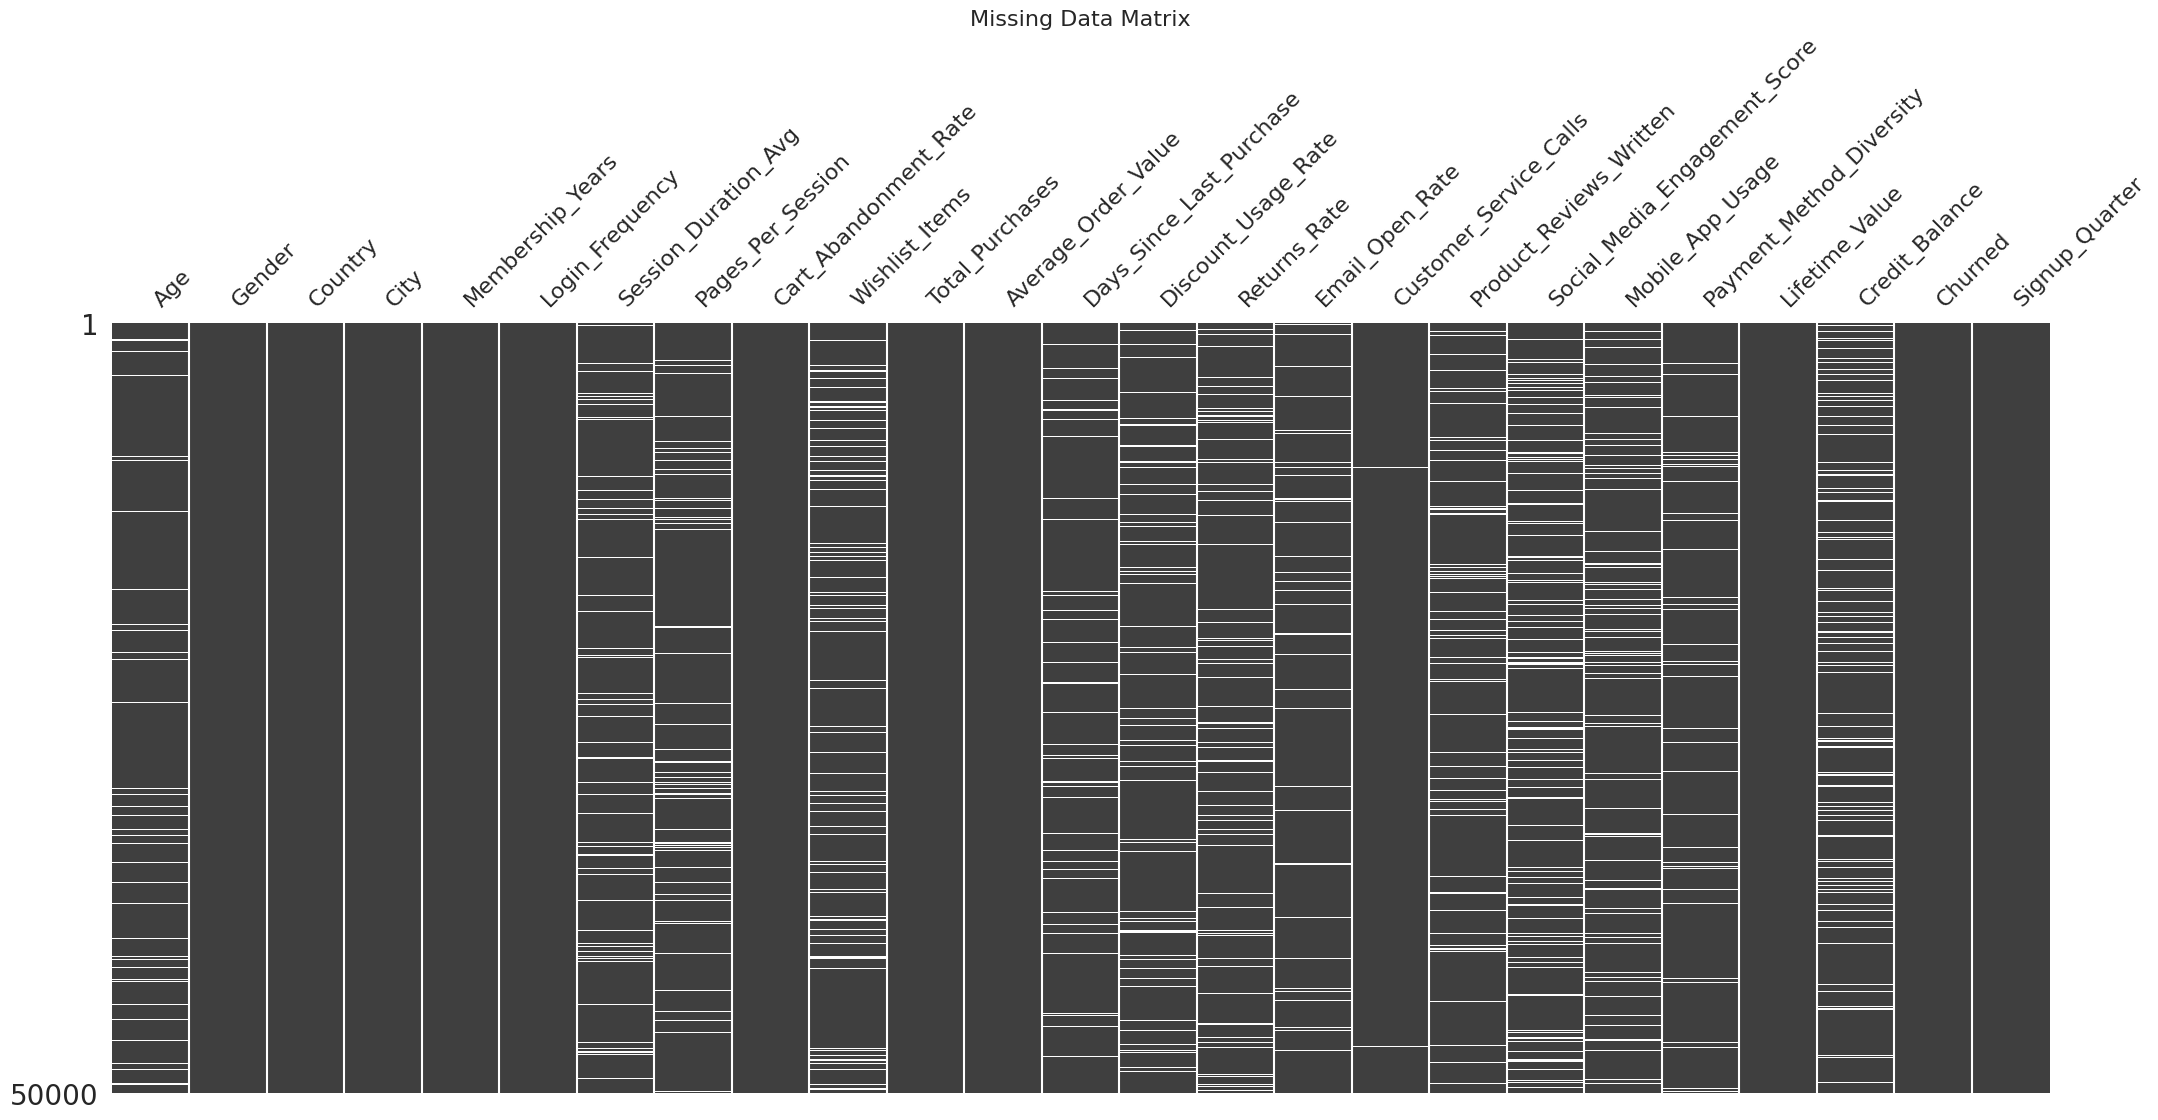

In [5]:
# Missing Data Visualization
plt.figure(figsize=(10, 6))
msno.matrix(df, sparkline=False)
plt.title("Missing Data Matrix", fontsize=16)
plt.show()

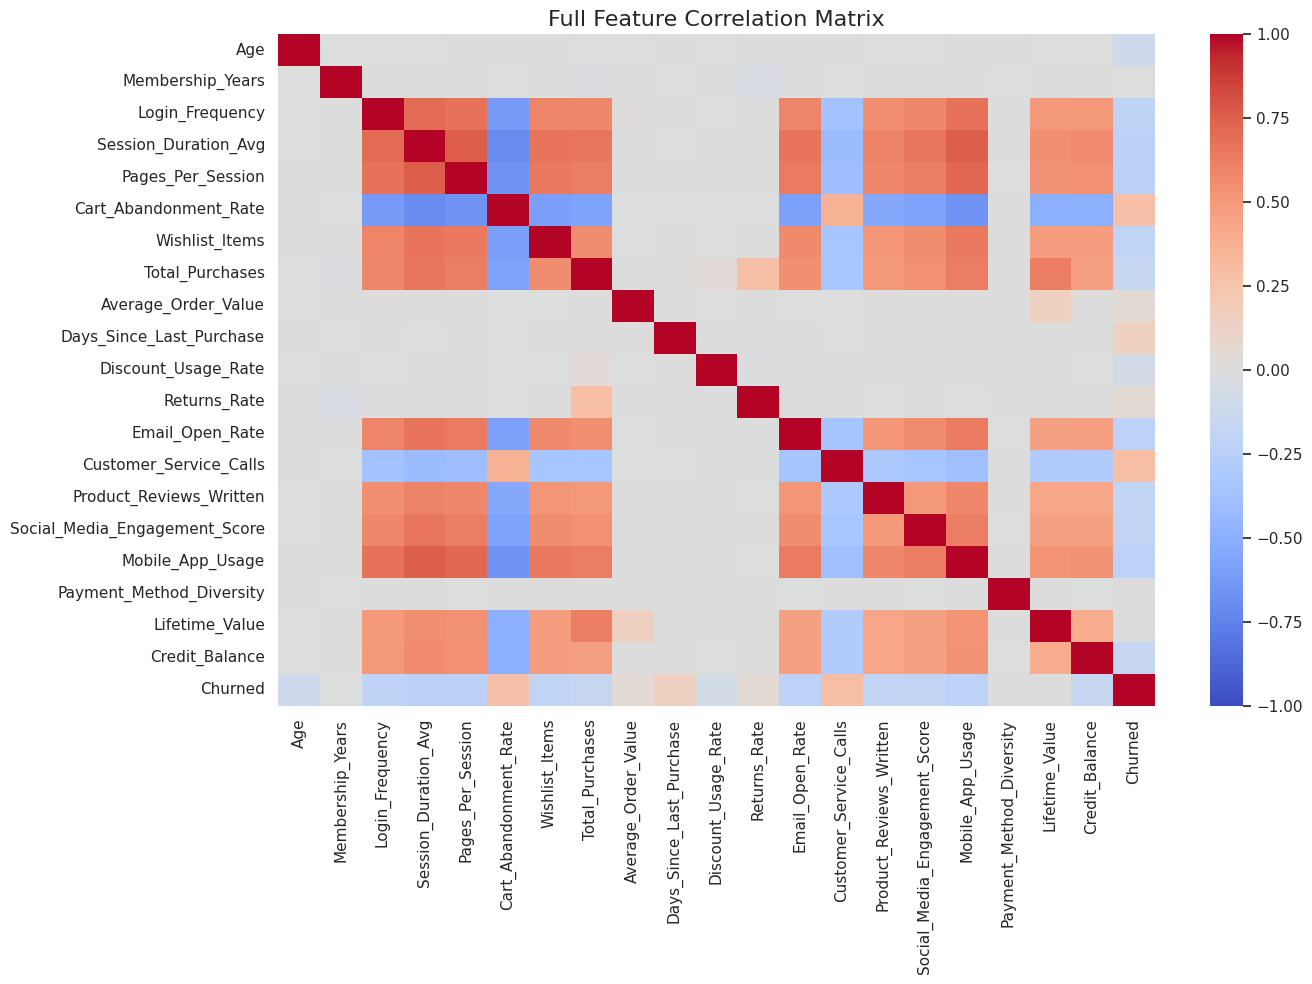

In [6]:
# Feature-to-Feature Correlation (Checking Multicollinearity)
plt.figure(figsize=(14, 10))
numerical_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Full Feature Correlation Matrix", fontsize=16)
plt.tight_layout()
plt.show()

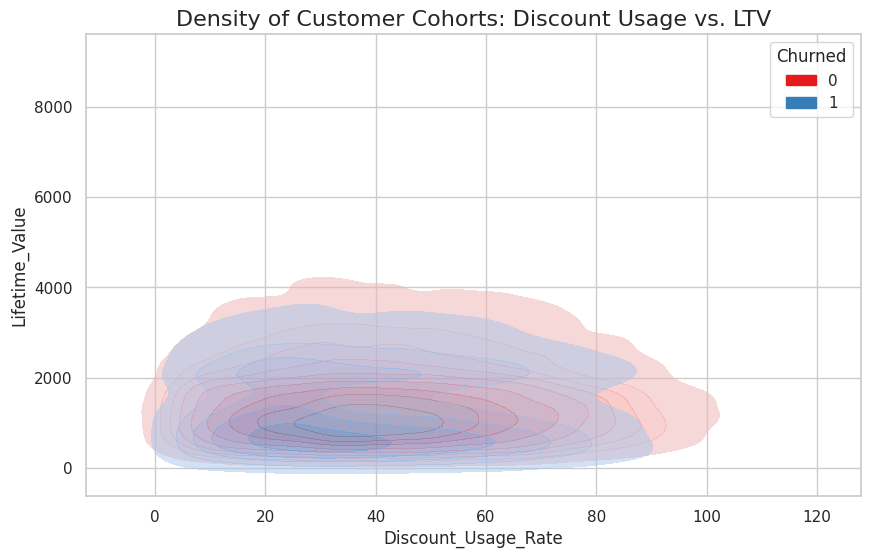

In [7]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Discount_Usage_Rate', y='Lifetime_Value', hue='Churned', fill=True, alpha=0.5, palette='Set1')
plt.title("Density of Customer Cohorts: Discount Usage vs. LTV", fontsize=16)
plt.show()

In [8]:
print("\n--- 2. PREPROCESSING & SPLITTING ---")
# Drop 'City' due to extremely high cardinality which destroys tree models
X = df.drop(columns=['Churned', 'City'])
y = df['Churned']


--- 2. PREPROCESSING & SPLITTING ---


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(f"Training records: {len(X_train)} | Testing records: {len(X_test)}")

Training records: 40000 | Testing records: 10000


In [10]:
# Define Column Groups
zero_fill_cols = ['Wishlist_Items', 'Returns_Rate', 'Customer_Service_Calls', 'Product_Reviews_Written', 'Social_Media_Engagement_Score']
categorical_cols = ['Gender', 'Country', 'Signup_Quarter']
knn_numeric_cols = [col for col in X_train.select_dtypes(include=[np.number]).columns if col not in zero_fill_cols]

In [11]:
# Build Transformers
zero_fill_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

knn_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()), # CRITICAL: Must scale before calculating KNN distances
    ('knn', KNNImputer(n_neighbors=5))
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])
# Combine into Preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('zero', zero_fill_transformer, zero_fill_cols),
    ('knn', knn_transformer, knn_numeric_cols),
    ('cat', cat_transformer, categorical_cols)
])

In [12]:
print("\n 3. BASELINE MODEL EVALUATION ")
baseline_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', DummyClassifier(strategy='prior'))])
baseline_pipeline.fit(X_train, y_train)
baseline_pred = baseline_pipeline.predict(X_test)
print(classification_report(y_test, baseline_pred, zero_division=0))


--- 3. BASELINE MODEL EVALUATION ---
              precision    recall  f1-score   support

           0       0.71      1.00      0.83      7110
           1       0.00      0.00      0.00      2890

    accuracy                           0.71     10000
   macro avg       0.36      0.50      0.42     10000
weighted avg       0.51      0.71      0.59     10000



In [13]:
print("\n--- 4. TUNED RANDOM FOREST EVALUATION ---")
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# Hyperparameter Grid
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 15, None],
    'classifier__min_samples_split': [2, 5, 10]
}


--- 4. TUNED RANDOM FOREST EVALUATION ---


In [14]:
# Cross-Validation on TRAINING data only
grid_search = RandomizedSearchCV(rf_pipeline, param_distributions=param_grid, n_iter=5, cv=3, scoring='roc_auc', n_jobs=-1, random_state=42)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Best Hyperparameters: {grid_search.best_params_}")

Best Hyperparameters: {'classifier__n_estimators': 100, 'classifier__min_samples_split': 5, 'classifier__max_depth': 15}


In [15]:
# Test Set Predictions
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(f"\nTuned ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred))


Tuned ROC-AUC Score: 0.9248
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      7110
           1       0.88      0.79      0.84      2890

    accuracy                           0.91     10000
   macro avg       0.90      0.88      0.89     10000
weighted avg       0.91      0.91      0.91     10000



/tmp/ipykernel_12185/503417152.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')


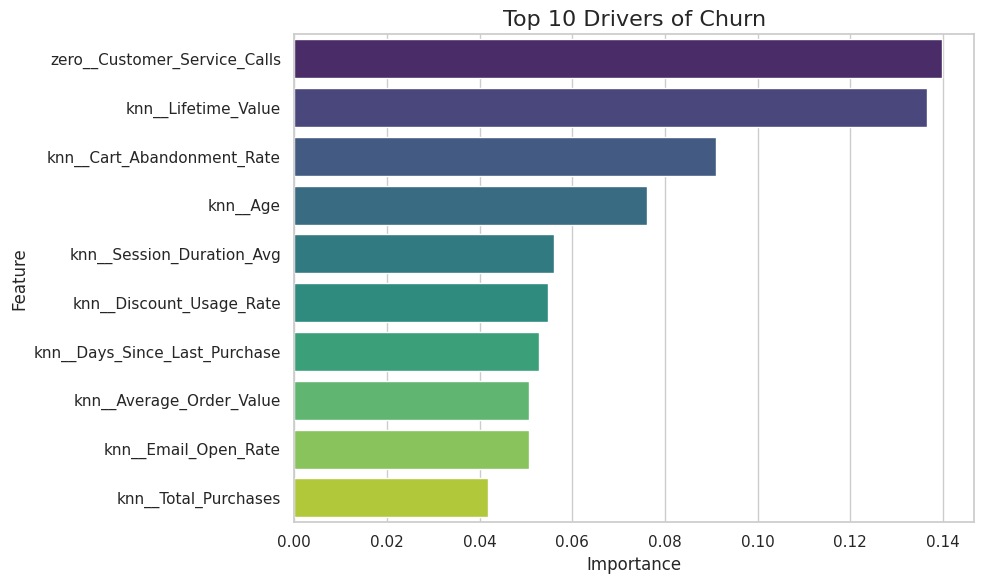

In [16]:
# Extract Feature Importances
importances = best_model.named_steps['classifier'].feature_importances_
feature_names = preprocessor.get_feature_names_out()
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
plt.title("Top 10 Drivers of Churn", fontsize=16)
plt.tight_layout()
plt.show()

In [17]:
print("\n--- 5. BUSINESS PROFIT OPTIMIZATION ---")
# Re-align with Test Set unscaled financial data
results_df = X_test.copy()
results_df['Actual_Churn'] = y_test
results_df['Predicted_Prob'] = y_prob

COST_OF_INTERVENTION_RATE = 0.15
SUCCESS_RATE = 0.70

profits = []
thresholds = np.linspace(0.1, 0.9, 50)

for threshold in thresholds:
    results_df['Target'] = np.where(results_df['Predicted_Prob'] >= threshold, 1, 0)
    cost = results_df['Lifetime_Value'] * COST_OF_INTERVENTION_RATE

    tp_mask = (results_df['Target'] == 1) & (results_df['Actual_Churn'] == 1)
    tp_profit = ((results_df['Lifetime_Value'] - cost) * SUCCESS_RATE)[tp_mask].sum()

    fp_mask = (results_df['Target'] == 1) & (results_df['Actual_Churn'] == 0)
    fp_loss = -cost[fp_mask].sum()

    fn_mask = (results_df['Target'] == 0) & (results_df['Actual_Churn'] == 1)
    fn_loss = -results_df['Lifetime_Value'][fn_mask].sum()

    profits.append(tp_profit + fp_loss + fn_loss)


--- 5. BUSINESS PROFIT OPTIMIZATION ---


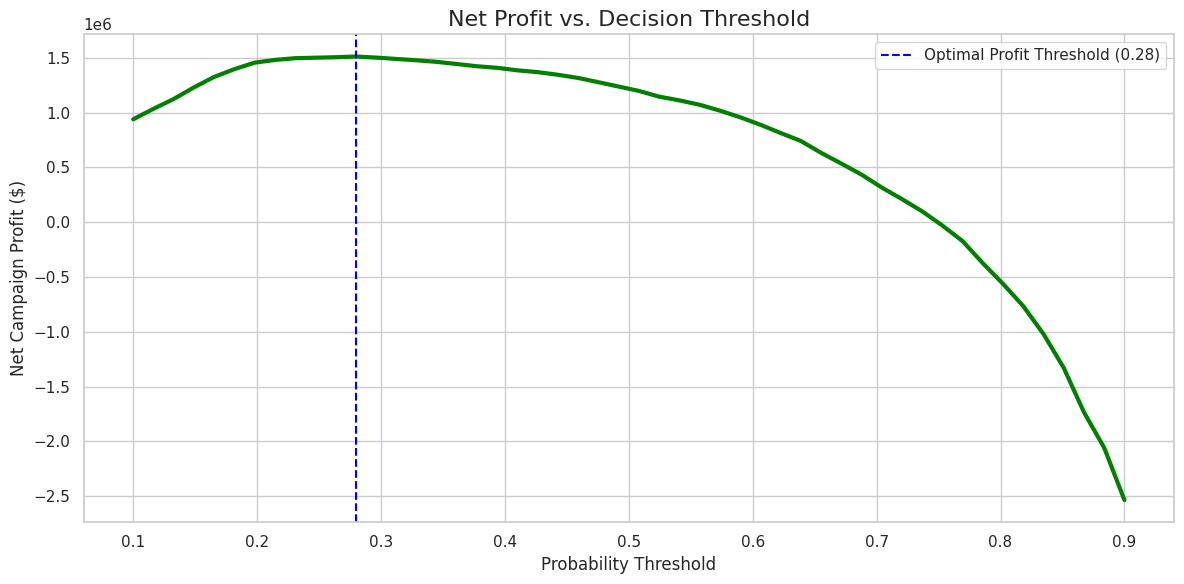

Optimal Threshold: 0.28
Maximized Profit: $1,510,960.47


In [18]:
# Visualization
plt.figure(figsize=(12, 6))
plt.plot(thresholds, profits, color='green', linewidth=3)
optimal_threshold = thresholds[profits.index(max(profits))]
plt.axvline(x=optimal_threshold, color='blue', linestyle='--', label=f'Optimal Profit Threshold ({optimal_threshold:.2f})')
plt.title("Net Profit vs. Decision Threshold", fontsize=16)
plt.xlabel("Probability Threshold")
plt.ylabel("Net Campaign Profit ($)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Optimal Threshold: {optimal_threshold:.2f}")
print(f"Maximized Profit: ${max(profits):,.2f}")

In [19]:
results_df['Prescriptive_Action'] = np.where(
    results_df['Predicted_Prob'] >= optimal_threshold,
    'Trigger Retention Campaign (15% Discount)',
    'Do Not Intervene'
)

In [21]:
# Merge Demographics back for dashboard filtering
export_df = pd.merge(
    results_df[['Actual_Churn', 'Predicted_Prob', 'Prescriptive_Action', 'Lifetime_Value']],
    df[['Country', 'City', 'Membership_Years']],
    left_index=True, right_index=True
)

export_df.to_csv('final_dashboard_data.csv', index=False)
print("\n PROCESS COMPLETE. 'final_dashboard_data.csv' EXPORTED FOR TABLEAU ")


 PROCESS COMPLETE. 'final_dashboard_data.csv' EXPORTED FOR TABLEAU 
